# 08 · Partial differential equations in two and three space dimensions

Axes: axis 0 is time, then the space axes in the order printed in the summary of
each record. These searches are long and are run from the command line; the
notebook shows the data, the signal check and, for the Navier–Stokes record, how
well the known and actually discovered equations reproduce the data in separate plots.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
import epde_bench.nbcache as notebook_cache
if os.environ.get('EPDE_BENCH_NOTEBOOK_CACHE'):
    notebook_cache.CACHE_DIR = Path(os.environ['EPDE_BENCH_NOTEBOOK_CACHE'])
from epde_bench.env import seed_everything
seed_everything(0)
from epde_bench.identity import _source_hash
print('Computation source SHA256:', _source_hash())
print('Search cache:', notebook_cache.CACHE_DIR)
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

Computation source SHA256: e9af6c769476a35197f9f9a7b0d4ad401ca7b0edeec5bda9c53b9f636b810aa0
Search cache: <repo>/projects/pic/results/notebook_execution_2026-10-09/search_cache
EPDE imported; notebook environment ready


## Navier–Stokes equations, wake behind a cylinder (Re = 100)

Two momentum equations and the continuity equation for the velocity $(u, v)$ and pressure $p$.

ns: Navier-Stokes, cylinder wake (Re = 100)
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, y, x; data shape: (50, 20, 36); variables: u, v, p
  t: [0, 4.9], 50 points
  y: [-1.592, 1.51], 20 points
  x: [1, 5.949], 36 points
  truth:
    -1.0 * u{power: 1.0} * du/dx2{power: 1.0} + -1.0 * v{power: 1.0} * du/dx1{power: 1.0} + -1.0 * dp/dx2{power: 1.0} + 0.01 * d^2u/dx2^2{power: 1.0} + 0.01 * d^2u/dx1^2{power: 1.0} = du/dx0{power: 1.0}
    -1.0 * u{power: 1.0} * dv/dx2{power: 1.0} + -1.0 * v{power: 1.0} * dv/dx1{power: 1.0} + -1.0 * dp/dx1{power: 1.0} + 0.01 * d^2v/dx2^2{power: 1.0} + 0.01 * d^2v/dx1^2{power: 1.0} = dv/dx0{power: 1.0}
    -1.0 * dv/dx1{power: 1.0} = du/dx2{power: 1.0}
  notes: Axes (t, y, x): dx1 = d/dy, dx2 = d/dx. Two momentum equations (nu = 0.01) and continuity. By default a subset of about 36 thousand points; the full window has 250 thousand points per variable.


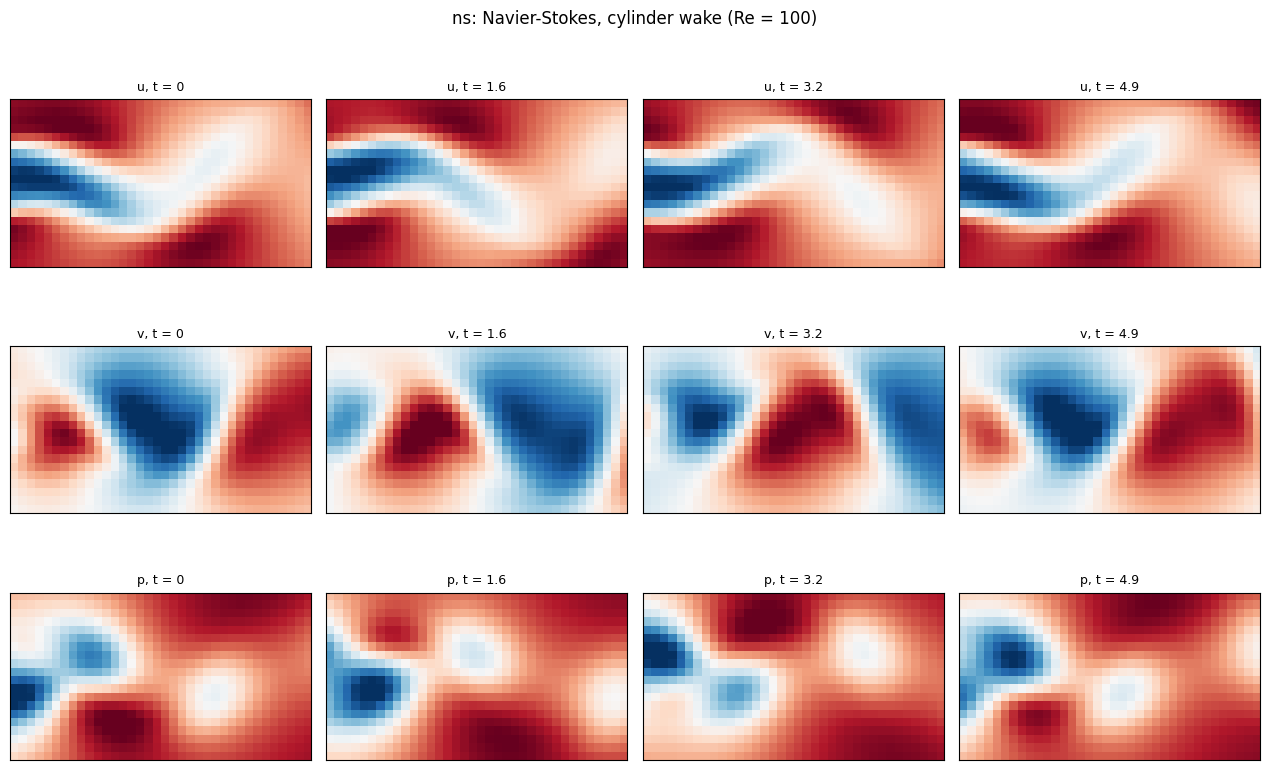

In [2]:
p = datasets.load('ns')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('ns', noise_levels=[0, 1])
print_check(p, report)

ns: Navier-Stokes, cylinder wake (Re = 100)
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, y, x; data shape: (50, 20, 36); variables: u, v, p
  t: [0, 4.9], 50 points
  y: [-1.592, 1.51], 20 points
  x: [1, 5.949], 36 points
  truth:
    -1.0 * u{power: 1.0} * du/dx2{power: 1.0} + -1.0 * v{power: 1.0} * du/dx1{power: 1.0} + -1.0 * dp/dx2{power: 1.0} + 0.01 * d^2u/dx2^2{power: 1.0} + 0.01 * d^2u/dx1^2{power: 1.0} = du/dx0{power: 1.0}
    -1.0 * u{power: 1.0} * dv/dx2{power: 1.0} + -1.0 * v{power: 1.0} * dv/dx1{power: 1.0} + -1.0 * dp/dx1{power: 1.0} + 0.01 * d^2v/dx2^2{power: 1.0} + 0.01 * d^2v/dx1^2{power: 1.0} = dv/dx0{power: 1.0}
    -1.0 * dv/dx1{power: 1.0} = du/dx2{power: 1.0}
  notes: Axes (t, y, x): dx1 = d/dy, dx2 = d/dx. Two momentum equations (nu = 0.01) and continuity. By default a subset of about 36 thousand points; the full window has 250 thousand points per variable.

=== noise 0 % ===
R^2 of the true structure: 0.999253   (du/dx0{power: 1.0})
  term      

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

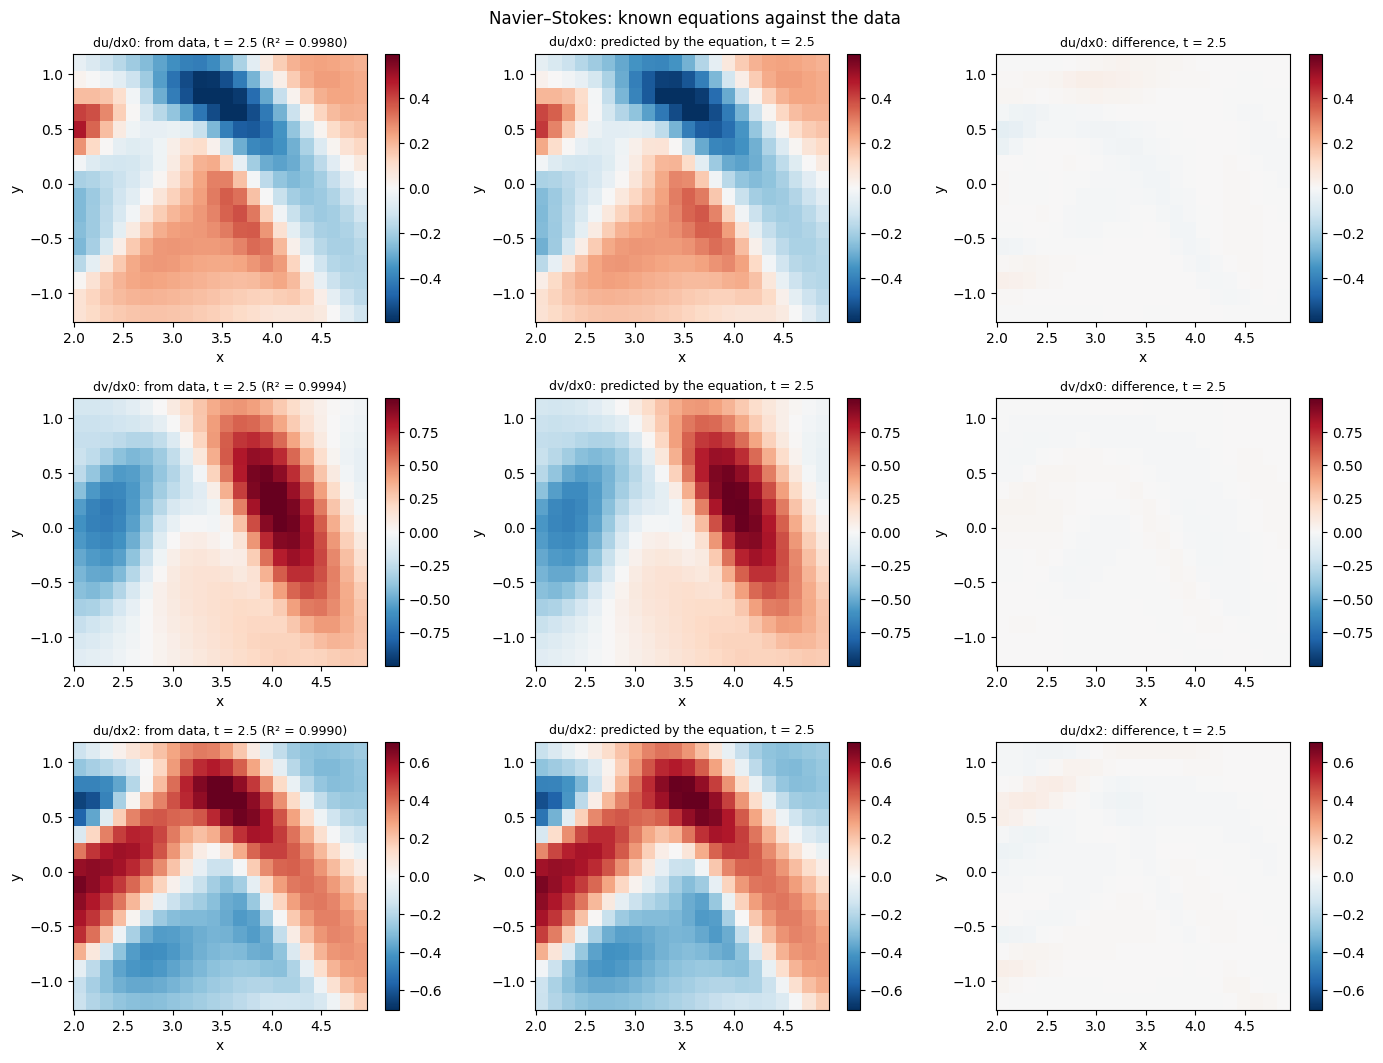

In [4]:
problem = datasets.load('ns')
search_cfg = resolve_for_problem(load_config('ns'), problem)
fig, scores = plot_reconstruction(problem, problem.truth, search_cfg, title='Navier–Stokes: known equations against the data')
plt.show()

## Discovered Navier–Stokes equations from the fresh campaign

The preceding plot evaluates the known law. This section instead reads the selected equations actually discovered by the clean-data campaign and evaluates their terms against the data. It does not launch a search. Failed or timed-out runs remain visible as statuses and do not receive a substitute plot of the known equations. This PDE comparison measures equation agreement on the supplied fields; it is not a held-out time forecast.

In [5]:
import json
from epde_bench.paths import RESULTS_DIR
campaign_name = os.environ.get('EPDE_BENCH_NOTEBOOK_CAMPAIGN', 'baseline_clean_2026-10-09')
ns_candidates = [RESULTS_DIR / campaign_name, PIC / 'experiments' / campaign_name]
ns_relative_record = Path('runs/ns/default__noise0__seed0.json')
ns_record_path = next((folder / ns_relative_record for folder in ns_candidates
                       if (folder / ns_relative_record).is_file()), None)
if ns_record_path is None:
    print('Navier–Stokes discovery record is unavailable:', ns_candidates)
else:
    ns_record = json.loads(ns_record_path.read_text(encoding='utf-8'))
    print('Saved discovery:', ns_record_path)
    print({key: ns_record.get(key) for key in
           ['dataset', 'variant', 'noise', 'seed', 'status', 'started', 'fit_seconds']})
    print('Computation identity:', {key: ns_record.get('identity', {}).get(key) for key in
          ['sha256', 'source_sha256', 'data_sha256']})
    print('Structural metrics:', ns_record.get('metrics'))
    if ns_record.get('status') == 'ok' and ns_record.get('selected'):
        print('Selected discovered equations:')
        for equation in ns_record['selected']:
            print(equation)
        ns_problem = datasets.load(ns_record['dataset'], **ns_record['config'].get('loader', {}))
        ns_data = ns_problem.noisy(ns_record['noise'], seed=ns_record['seed'])
        ns_search_cfg = ns_record.get('search_config') or resolve_for_problem(ns_record['config'], ns_problem)
        fig, ns_scores = plot_reconstruction(ns_problem, ns_record['selected'], ns_search_cfg,
                                             data=ns_data, title='Navier–Stokes: discovered equations against the data')
        plt.show()
        print('Agreement with the supplied fields:', ns_scores)
    else:
        print('No discovered-equation plot:', ns_record.get('error',
              ns_record.get('reason', ns_record.get('status'))))

Saved discovery: <repo>/projects/pic/results/baseline_clean_2026-10-09/runs/ns/default__noise0__seed0.json
{'dataset': 'ns', 'variant': 'default', 'noise': 0.0, 'seed': 0, 'status': 'timeout', 'started': None, 'fit_seconds': None}
Computation identity: {'sha256': '3a8024a10107e776444fb169623aa3dce2b1000e2540283a13f7925c127abd05', 'source_sha256': '9e213a88371bed42376fd17fa31b236c6d7d920b91003fb1e5d7e82921b876d0', 'data_sha256': '9c29af77348ccf086e8bdc5aac8eca8ce04d30b7dfa7cafdb52c96b26191fa33'}
Structural metrics: None
No discovered-equation plot: timeout


## Isotropic turbulence, two-dimensional slice of a direct numerical simulation

The momentum equations restricted to a plane. Transport across the plane and the pressure and viscous terms enter as supplied fields. Checks and searches use clean data only: the supplied gradients are noise-free.

jhtdb_plane: Isotropic turbulence, 2-D slice of JHTDB
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, y, x; data shape: (40, 48, 48); variables: u, v
  t: [0.5, 0.578], 40 points
  y: [1, 3.307], 48 points
  x: [1, 3.307], 48 points
  truth:
    -1.0 * u{power: 1.0} * du/dx2{power: 1.0} + -1.0 * v{power: 1.0} * du/dx1{power: 1.0} + -1.0 * w{power: 1.0} * u_z{power: 1.0} + -1.0 * p_x{power: 1.0} + 1.0 * nu_lap_u{power: 1.0} = du/dx0{power: 1.0}
    -1.0 * u{power: 1.0} * dv/dx2{power: 1.0} + -1.0 * v{power: 1.0} * dv/dx1{power: 1.0} + -1.0 * w{power: 1.0} * v_z{power: 1.0} + -1.0 * p_y{power: 1.0} + 1.0 * nu_lap_v{power: 1.0} = dv/dx0{power: 1.0}
  notes: 48 x 48 slice (stride 8 of the DNS grid), 40 frames. Too coarse for numerical derivatives (aliased), so the exact server-side gradients are passed instead; out-of-plane and pressure terms enter as exact tokens. Artificial noise is unsupported with these supplied derivatives; use noise=0.


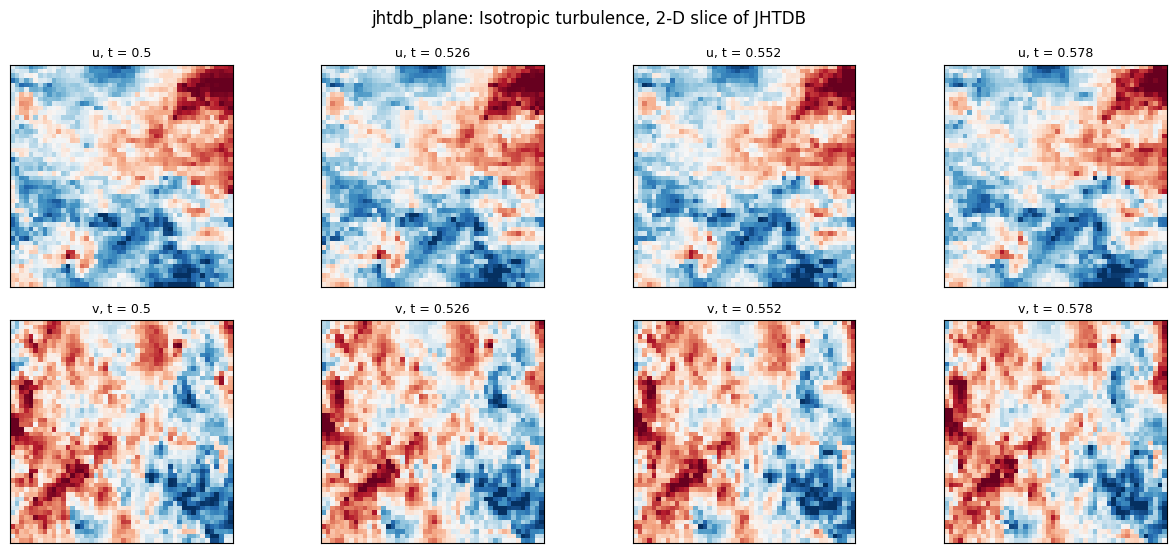

In [6]:
p = datasets.load('jhtdb_plane')
print(p.summary())
plot_problem(p); plt.show()

In [7]:
p, report = check('jhtdb_plane', noise_levels=[0])
print_check(p, report)

jhtdb_plane: Isotropic turbulence, 2-D slice of JHTDB
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, y, x; data shape: (40, 48, 48); variables: u, v
  t: [0.5, 0.578], 40 points
  y: [1, 3.307], 48 points
  x: [1, 3.307], 48 points
  truth:
    -1.0 * u{power: 1.0} * du/dx2{power: 1.0} + -1.0 * v{power: 1.0} * du/dx1{power: 1.0} + -1.0 * w{power: 1.0} * u_z{power: 1.0} + -1.0 * p_x{power: 1.0} + 1.0 * nu_lap_u{power: 1.0} = du/dx0{power: 1.0}
    -1.0 * u{power: 1.0} * dv/dx2{power: 1.0} + -1.0 * v{power: 1.0} * dv/dx1{power: 1.0} + -1.0 * w{power: 1.0} * v_z{power: 1.0} + -1.0 * p_y{power: 1.0} + 1.0 * nu_lap_v{power: 1.0} = dv/dx0{power: 1.0}
  notes: 48 x 48 slice (stride 8 of the DNS grid), 40 frames. Too coarse for numerical derivatives (aliased), so the exact server-side gradients are passed instead; out-of-plane and pressure terms enter as exact tokens. Artificial noise is unsupported with these supplied derivatives; use noise=0.

=== noise 0 % ===
R^2 of the tru

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

## Heat in soil under solar forcing, two-dimensional

Two-dimensional version of the soil record; the law is not scored.

heat_solar_2d: Heat in soil under solar forcing, 2-D
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, x, y; data shape: (144, 51, 51); variables: u
  t: [300, 1.719e+05], 144 points
  x: [-0.375, 0.375], 51 points
  y: [-1.5, 0], 51 points
  truth: unknown
  notes: 2-D version of heat_solar_1d (576 x 51 x 51 before striding in t).


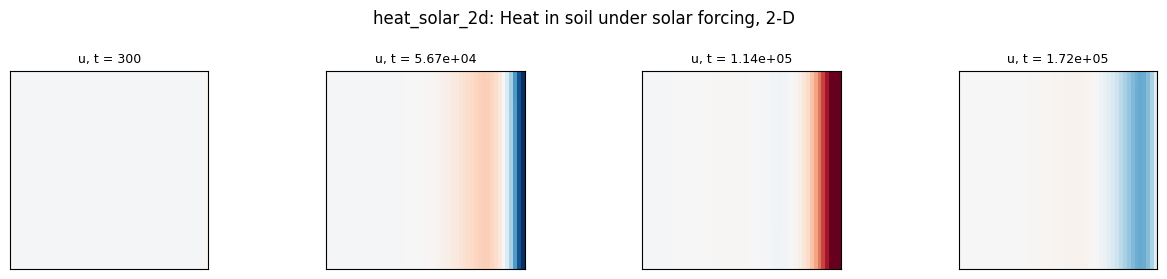

In [8]:
p = datasets.load('heat_solar_2d')
print(p.summary())
plot_problem(p); plt.show()

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

## Heat equation with a moving laser source, three-dimensional

Only 3 points along the depth and 20 in time, so those derivatives are crude. The source is supplied as a field. The law is not scored.

heat_laser: Heat equation with a moving laser source, 3-D
  class: PDE, 3 space dimensions, source: synthetic
  axes: t, x, y, z; data shape: (20, 51, 51, 3); variables: u
  t: [0, 1.9], 20 points
  x: [0, 0.1], 51 points
  y: [0, 0.1], 51 points
  z: [0, 0.001], 3 points
  truth: unknown
  notes: Only 3 points along z and 20 in t, so z- and t-derivatives are crude. The laser source is supplied as a field in (t, x, y), assumed uniform in z. No truth is scored.


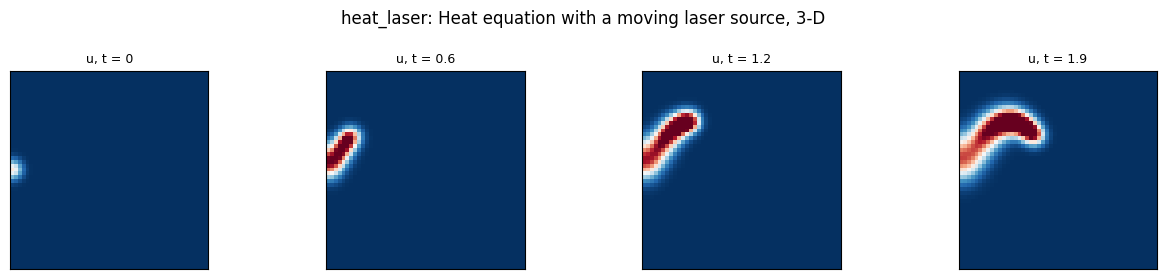

In [9]:
p = datasets.load('heat_laser')
print(p.summary())
plot_problem(p); plt.show()

This section does not run a discovery. The data and checks shown here do not establish that an equation was recovered. A full search can be launched from the command line or the app; no run time or success is claimed here.

## Darcy flow

The record for the Darcy flow problem $-\nabla\cdot(\nu \nabla u) = 1$ is kept,
but its data files are not part of the repository, so no check or search is run.
This is missing data, not a failure of the method.